In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/PS_20174392719_1491204439457_log.csv")

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [7]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [8]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [12]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

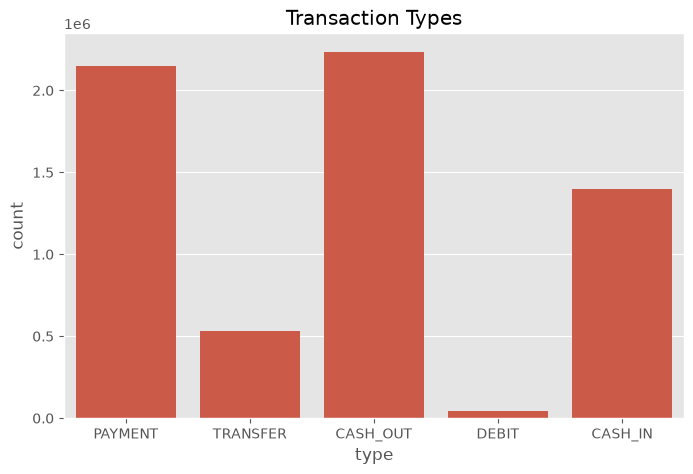

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="type")

plt.title("Transaction Types")

plt.show()

In [14]:
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


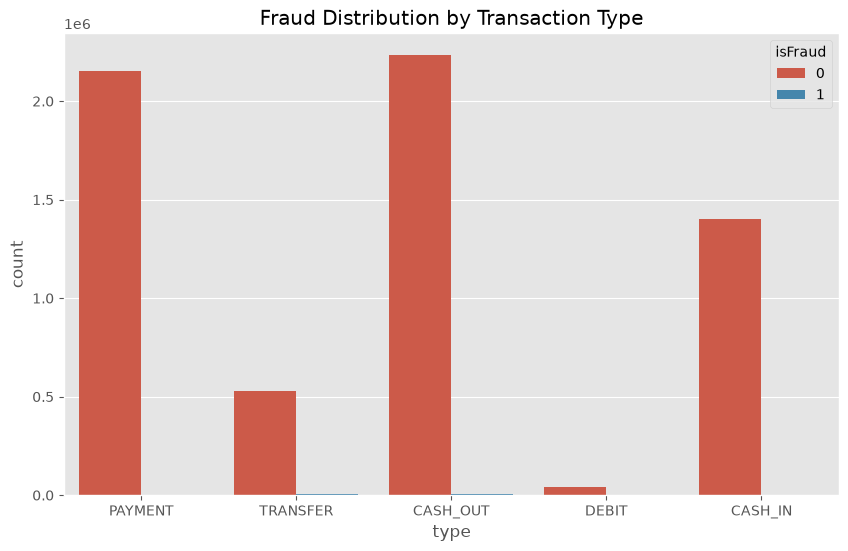

In [15]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="type",
    hue="isFraud"
)

plt.title("Fraud Distribution by Transaction Type")

plt.show()

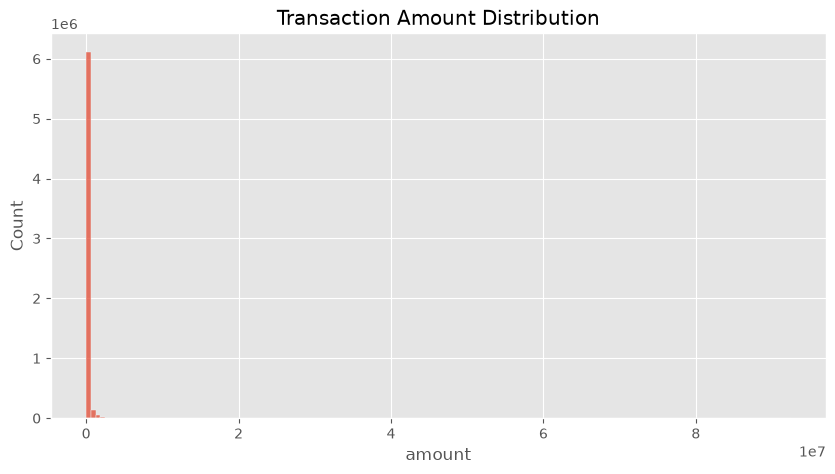

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["amount"],
    bins=150
)

plt.title("Transaction Amount Distribution")

plt.show()

In [20]:
numerical_cols = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

df[numerical_cols].describe()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06
std,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05
75%,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06
max,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08


In [21]:
from sklearn.preprocessing import LabelEncoder

temp = df.copy()

le = LabelEncoder()

temp["type"] = le.fit_transform(temp["type"])

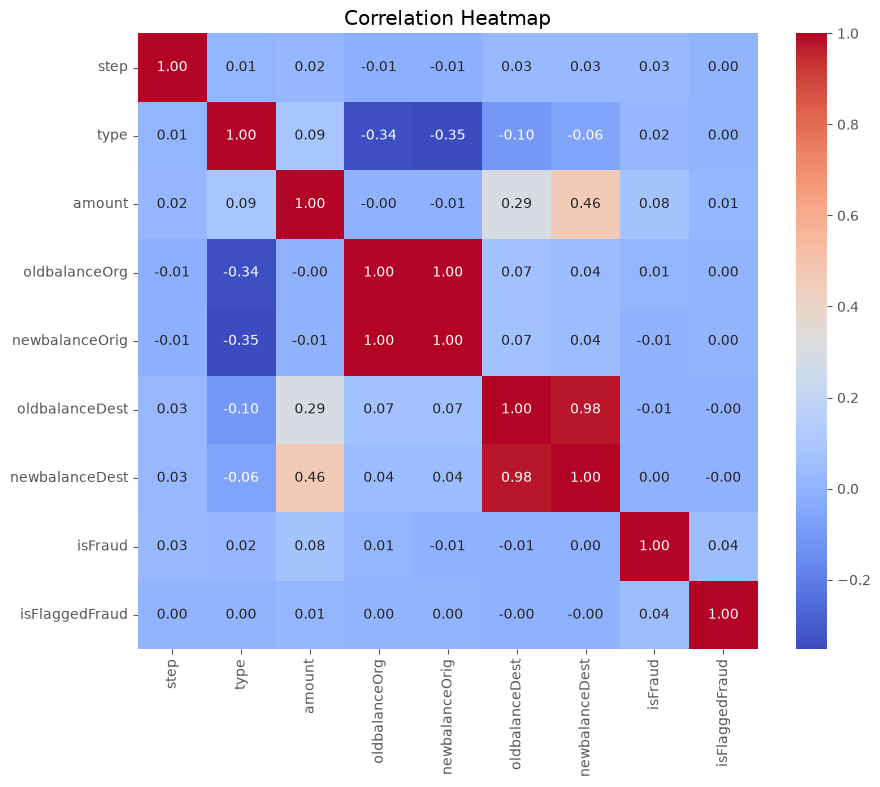

In [39]:
temp = df.copy()

encoder = LabelEncoder()
temp["type"] = encoder.fit_transform(temp["type"])

numeric_df = temp.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [40]:
temp.drop(columns=["nameOrig", "nameDest"], inplace=True)

In [41]:
temp.drop(columns=["isFlaggedFraud"], inplace=True)

In [42]:
temp["originBalanceDiff"] = (
    data["oldbalanceOrg"] - data["newbalanceOrig"]
)

In [43]:
temp["destBalanceDiff"] = (
    data["newbalanceDest"] - data["oldbalanceDest"]
)

In [44]:
temp["balanceChanged"] = (
    data["originBalanceDiff"] != 0
).astype(int)

In [45]:
threshold = temp["amount"].quantile(0.95)

temp["largeTransaction"] = (
    temp["amount"] > threshold
).astype(int)

In [32]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [47]:
temp.to_parquet(
    "../data/paysim_feature_engineered.parquet",
    index=False
)

In [46]:
temp.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,originBalanceDiff,destBalanceDiff,balanceChanged,largeTransaction
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0,1,0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0,1,0
2,1,4,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0,1,0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0,1,0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0,1,0
